**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.


# 04. MCMC Bayesian Inference
This notebook demonstrates practical Bayesian modeling workflows with Numerics MCMC samplers.

## What You'll Learn

- Real-world Bayesian inference examples
- Comparing different MCMC samplers (RWMH vs DEMCz)
- Posterior predictive checks
- Model comparison

## Setup


In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy import stats

# Load Numerics DLL (auto-discovered from NuGet; see notebook 00 for details)
from helper_functions import resolve_numerics_dll
clr.AddReference(str(resolve_numerics_dll()))

# Import MCMC classes
from Numerics.Sampling.MCMC import RWMH, DEMCzs, MCMCResults, LogLikelihood, MCMCSampler
from Numerics.Distributions import Normal, Uniform, Logistic, Gumbel, IUnivariateDistribution
from Numerics.Mathematics.LinearAlgebra import Matrix
from System import Array, Double
from System.Collections.Generic import List

print("✓ Setup complete")

✓ Setup complete


In [2]:
from System.Threading import ThreadPool
import os

''' NOTE FOR DEMO USERS:
When calling Numerics MCMC samplers from Python via pythonnet, the samplers'
internal parallel chains (Parallel.For) contend for Python's Global Interpreter
Lock (GIL). This makes parallel execution slower than sequential. Setting
max thread pool workers to 1 forces sequential execution and removes that
overhead. In pure C#, you can remove this line and parallelism will work as
intended. 

This is also why we set sampler.ParallelizeChains = False for every example.
It defaults to True, which works well in C#, but it slows the sampler down 
in Python'''
ThreadPool.SetMaxThreads(1, 1)  # (workerThreads, completionPortThreads)

# Optional: restore .NET thread pool after demos if needed
# def _restore_dotnet_threadpool():
#     cpu_count = os.cpu_count() or 1
#     ThreadPool.SetMaxThreads(cpu_count, cpu_count)

False

## Example: Flood Frequency Analysis

Problem: We have annual peak flow data and want to estimate distribution parameters with uncertainty. To do this we will use Bayesian inference through a MCMC sampler!

Data Source: Tippecanoe River Near Delphi, Indiana (from "Flood Frequency Analysis", A.R. Rao & K.H. Hamed, CRC Press, 2000)


Flood Dataset Summary


,Metric,Value
0,Count,48.00
1,Sample mean (cfs),12665.21
2,Sample std (cfs),4709.74
3,Min (cfs),2700.00
4,Max (cfs),22600.00


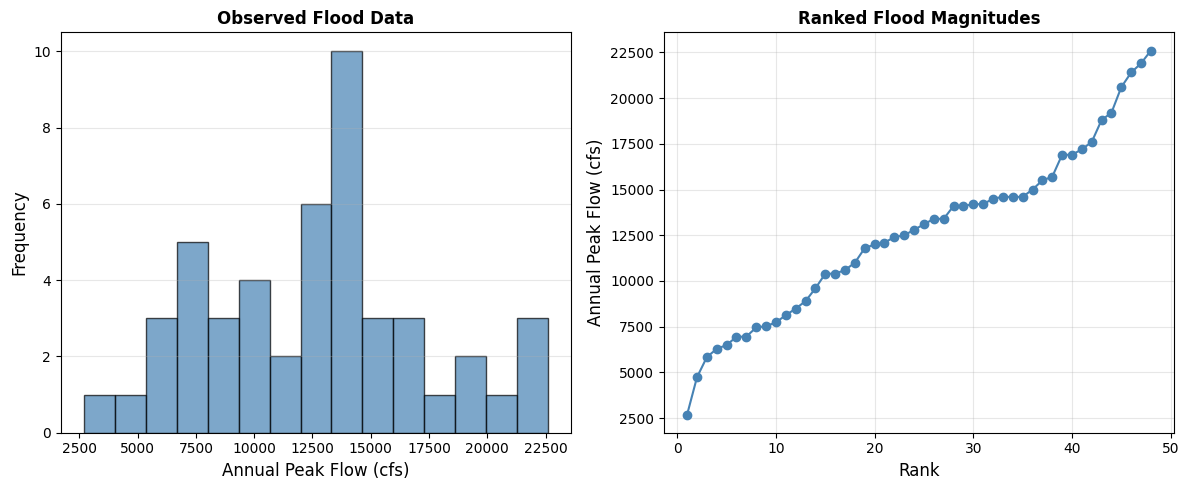

In [3]:
flood_data = Array[Double]([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000, 
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600, 
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600, 
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600, 
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460
])

flood_np = np.array(list(flood_data))
summary_df = pd.DataFrame({
    'Metric': ['Count','Sample mean (cfs)','Sample std (cfs)','Min (cfs)','Max (cfs)'],
    'Value': [flood_data.Length, np.mean(flood_np), np.std(flood_np, ddof=1), np.min(flood_np), np.max(flood_np)]
})
print('Flood Dataset Summary')
display(summary_df.round(2))

# Visualize data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(flood_data, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Annual Peak Flow (cfs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Observed Flood Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
sorted_data = sorted(list(flood_data))
plt.plot(range(1, len(sorted_data)+1), sorted_data, 'o-', color='steelblue')
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Annual Peak Flow (cfs)', fontsize=12)
plt.title('Ranked Flood Magnitudes', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Fit a Normal Distribution
We'll estimate $\mu$ and $\sigma$ for a Normal distribution using Bayesian inference. Recall how we define a MCMC sampler and its necessary inputs from notebook 03.


Prior for μ: Uniform(-1000000, 1000000)
Prior for σ: Uniform(0, 100000)
Running RWMH sampler...
✓ RWMH complete (7.976 seconds)

Logistic Distribution Results


,Parameter,Posterior Mean,Lower 90% CI,Upper 90% CI
0,μ (mean),12664.47,11495.65,13813.18
1,σ (std dev),4834.05,4071.96,5745.79


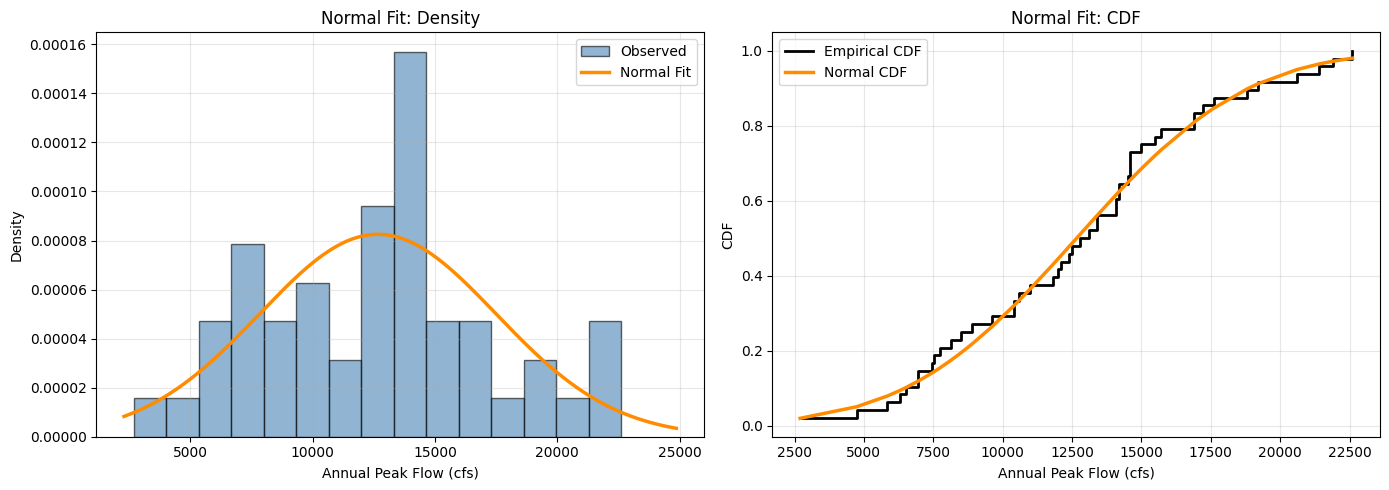

In [4]:
# Create uniform priors based on data constraints
norm_dist = Normal()
constraints = norm_dist.GetParameterConstraints(flood_data)

mu_prior = Uniform(constraints.Item2[0], constraints.Item3[0])
sigma_prior = Uniform(constraints.Item2[1], constraints.Item3[1])

print(f"Prior for μ: Uniform({mu_prior.Minimum:.0f}, {mu_prior.Maximum:.0f})")
print(f"Prior for σ: Uniform({sigma_prior.Minimum:.0f}, {sigma_prior.Maximum:.0f})")

# Create prior list
priors = List[IUnivariateDistribution]()
priors.Add(mu_prior)
priors.Add(sigma_prior)

# Define log-likelihood
def log_likelihood_normal(params):
    mu = params[0]
    sigma = params[1]
    dist = Normal(mu, sigma)
    return dist.LogLikelihood(flood_data)

# Recall we have to wrap the Python function as a .NET Func
log_lik_func = LogLikelihood(log_likelihood_normal)


# Run RWMH sampler
print("Running RWMH sampler...")
start_rwmh = time.perf_counter()
sampler_rwmh = RWMH(priors, log_lik_func, Matrix(2))
sampler_rwmh.ParallelizeChains = False
sampler_rwmh.Initialize = MCMCSampler.InitializationType.MAP
sampler_rwmh.Sample()
time_rwmh = time.perf_counter() - start_rwmh
results_rwmh = MCMCResults(sampler_rwmh)
print(f"✓ RWMH complete ({time_rwmh:.3f} seconds)")

# Extract samples
rwmh_mu = [results_rwmh.MarkovChains[0][i].Values[0] for i in range(len(results_rwmh.MarkovChains[0]))]
rwmh_sigma = [results_rwmh.MarkovChains[0][i].Values[1] for i in range(len(results_rwmh.MarkovChains[0]))]

mu_stats = results_rwmh.ParameterResults[0].SummaryStatistics
sigma_stats = results_rwmh.ParameterResults[1].SummaryStatistics
results_table = pd.DataFrame([
    {'Parameter':'μ (mean)','Posterior Mean':mu_stats.Mean,'Lower 90% CI':mu_stats.LowerCI,'Upper 90% CI':mu_stats.UpperCI},
    {'Parameter':'σ (std dev)','Posterior Mean':sigma_stats.Mean,'Lower 90% CI':sigma_stats.LowerCI,'Upper 90% CI':sigma_stats.UpperCI},
])
print("\nLogistic Distribution Results")
display(results_table.round(2))

# Graph fitted Logistic distribution vs observed data
flood_np = np.array(list(flood_data))
fitted_normal = Normal(mu_stats.Mean, sigma_stats.Mean)
x_plot = np.linspace(flood_np.min() * 0.85, flood_np.max() * 1.10, 500)

fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))
ax_pdf.hist(flood_np, bins=15, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Observed')
ax_pdf.plot(x_plot, [fitted_normal.PDF(xi) for xi in x_plot], color='darkorange', linewidth=2.5, label='Normal Fit')
ax_pdf.set_xlabel('Annual Peak Flow (cfs)')
ax_pdf.set_ylabel('Density')
ax_pdf.set_title('Normal Fit: Density')
ax_pdf.legend()
ax_pdf.grid(True, alpha=0.3)

sorted_obs = np.sort(flood_np)
ecdf = np.arange(1, len(sorted_obs) + 1) / len(sorted_obs)
ax_cdf.step(sorted_obs, ecdf, where='post', color='black', linewidth=2, label='Empirical CDF')
ax_cdf.plot(sorted_obs, [fitted_normal.CDF(v) for v in sorted_obs], color='darkorange', linewidth=2.5, label='Normal CDF')
ax_cdf.set_xlabel('Annual Peak Flow (cfs)')
ax_cdf.set_ylabel('CDF')
ax_cdf.set_title('Normal Fit: CDF')
ax_cdf.legend()
ax_cdf.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Fit a Logistic Distribution
From the data we'll estimate $\xi$ and $\alpha$ for a Logistic distribution using Bayesian inference. The Logistic distribution is often used for growth models and has heavier tails than Normal [[1]](#1).


Fitting Logistic distribution with RWMH...
RWMH Complete (9.516 seconds)

Logistic Distribution Results


,Parameter,Posterior Mean,Lower 90% CI,Upper 90% CI
0,ξ (location),12631.70,11462.57,13799.42
1,α (scale),2820.52,2305.09,3435.53


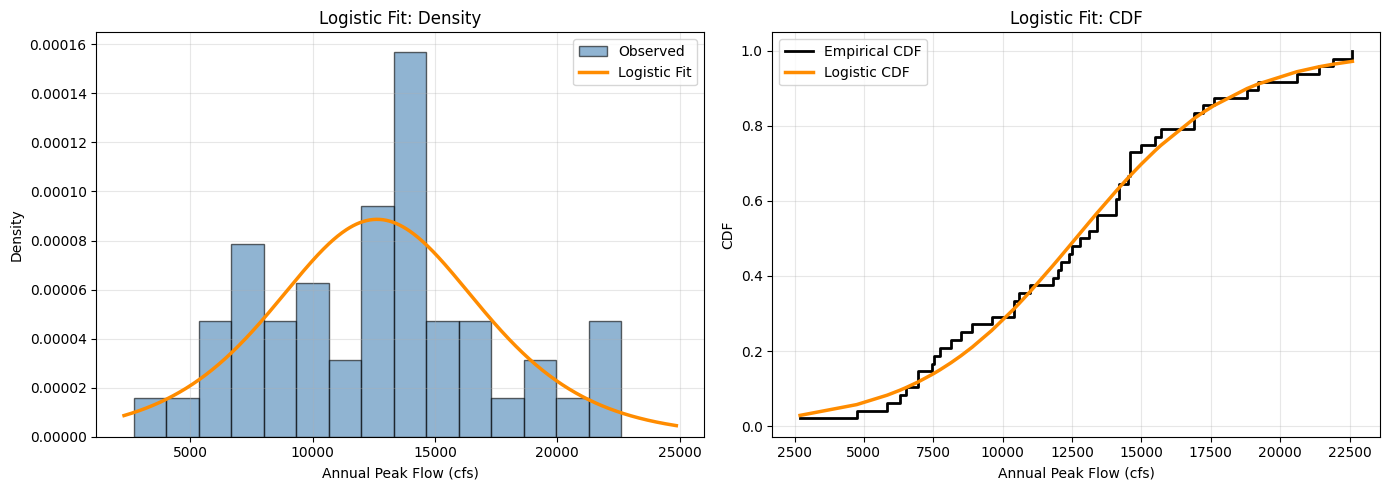

In [5]:
# Create priors for Logistic distribution
logistic_dist = Logistic()
constraints_log = logistic_dist.GetParameterConstraints(flood_data)

xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])

priors_logistic = List[IUnivariateDistribution]()
priors_logistic.Add(xi_prior)
priors_logistic.Add(alpha_prior)

# Define log-likelihood
def log_likelihood_logistic(params):
    xi = params[0]
    alpha = params[1]
    dist = Logistic(xi, alpha)
    return dist.LogLikelihood(flood_data)

log_lik_logistic = LogLikelihood(log_likelihood_logistic)

# Run DEMCzs
print("Fitting Logistic distribution with RWMH...")
start = time.perf_counter()
sampler_logistic = RWMH(priors_logistic, log_lik_logistic, Matrix(2))
sampler_logistic.ParallelizeChains = False
sampler_logistic.Initialize = MCMCSampler.InitializationType.MAP
sampler_logistic.Sample()
elapsed = time.perf_counter() - start
results_logistic = MCMCResults(sampler_logistic)
print(f"RWMH Complete ({elapsed:.3f} seconds)")

xi_stats = results_logistic.ParameterResults[0].SummaryStatistics
alpha_stats = results_logistic.ParameterResults[1].SummaryStatistics
results_table = pd.DataFrame([
    {'Parameter':'ξ (location)','Posterior Mean':xi_stats.Mean,'Lower 90% CI':xi_stats.LowerCI,'Upper 90% CI':xi_stats.UpperCI},
    {'Parameter':'α (scale)','Posterior Mean':alpha_stats.Mean,'Lower 90% CI':alpha_stats.LowerCI,'Upper 90% CI':alpha_stats.UpperCI},
])
print("\nLogistic Distribution Results")
display(results_table.round(2))

# Graph fitted Logistic distribution vs observed data
flood_np = np.array(list(flood_data))
fitted_logistic = Logistic(xi_stats.Mean, alpha_stats.Mean)
x_plot = np.linspace(flood_np.min() * 0.85, flood_np.max() * 1.10, 500)

fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))
ax_pdf.hist(flood_np, bins=15, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Observed')
ax_pdf.plot(x_plot, [fitted_logistic.PDF(xi) for xi in x_plot], color='darkorange', linewidth=2.5, label='Logistic Fit')
ax_pdf.set_xlabel('Annual Peak Flow (cfs)')
ax_pdf.set_ylabel('Density')
ax_pdf.set_title('Logistic Fit: Density')
ax_pdf.legend()
ax_pdf.grid(True, alpha=0.3)

sorted_obs = np.sort(flood_np)
ecdf = np.arange(1, len(sorted_obs) + 1) / len(sorted_obs)
ax_cdf.step(sorted_obs, ecdf, where='post', color='black', linewidth=2, label='Empirical CDF')
ax_cdf.plot(sorted_obs, [fitted_logistic.CDF(v) for v in sorted_obs], color='darkorange', linewidth=2.5, label='Logistic CDF')
ax_cdf.set_xlabel('Annual Peak Flow (cfs)')
ax_cdf.set_ylabel('CDF')
ax_cdf.set_title('Logistic Fit: CDF')
ax_cdf.legend()
ax_cdf.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Comparing Multiple Distribution Fits

Let's fit several candidate distributions and compare their fit to the flood data. We have already walked through Normal and Logistic fits, and now we will add a Gumbel. We will graph the fits and compare the posterior parameters.


Fitting Gumbel distribution...
✓ Complete


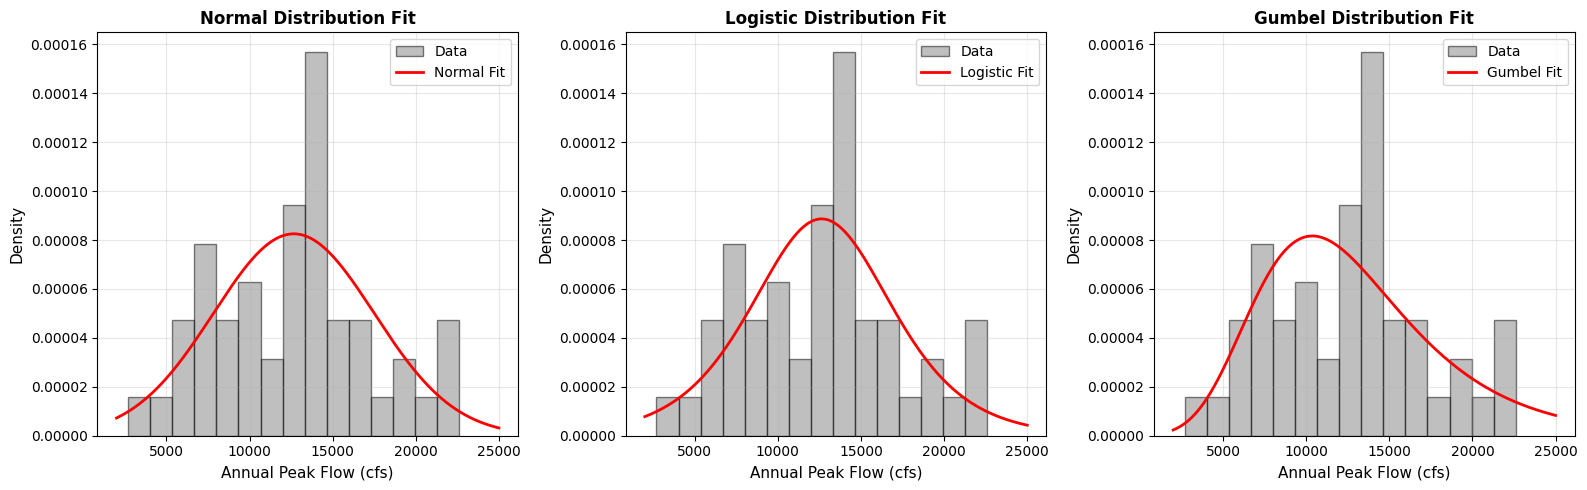

MODEL COMPARISON


,Distribution,Parameter 1,Parameter 2
0,Normal,μ = 12664,σ = 4834
1,Logistic,ξ = 12632,α = 2821
2,Gumbel,ξ = 10369,α = 4506


In [6]:
# We already have Normal and Logistic results
# Let's add Gumbel
gumbel_dist = Gumbel()
constraints_gum = gumbel_dist.GetParameterConstraints(flood_data)

xi_prior_g = Uniform(constraints_gum.Item2[0], constraints_gum.Item3[0])
alpha_prior_g = Uniform(constraints_gum.Item2[1], constraints_gum.Item3[1])

priors_gumbel = List[IUnivariateDistribution]()
priors_gumbel.Add(xi_prior_g)
priors_gumbel.Add(alpha_prior_g)

def log_likelihood_gumbel(params):
    dist = Gumbel(params[0], params[1])
    return dist.LogLikelihood(flood_data)

log_lik_gumbel = LogLikelihood(log_likelihood_gumbel)

print("Fitting Gumbel distribution...")
sampler_gumbel = RWMH(priors_gumbel, log_lik_gumbel, Matrix(2))
sampler_gumbel.ParallelizeChains = False
sampler_gumbel.Initialize = MCMCSampler.InitializationType.MAP
sampler_gumbel.Sample()
results_gumbel = MCMCResults(sampler_gumbel)
print("✓ Complete")

# Extract parameter samples
normal_mu_mean = results_rwmh.ParameterResults[0].SummaryStatistics.Mean
normal_sigma_mean = results_rwmh.ParameterResults[1].SummaryStatistics.Mean

logistic_xi_mean = results_logistic.ParameterResults[0].SummaryStatistics.Mean
logistic_alpha_mean = results_logistic.ParameterResults[1].SummaryStatistics.Mean

gumbel_xi_mean = results_gumbel.ParameterResults[0].SummaryStatistics.Mean
gumbel_alpha_mean = results_gumbel.ParameterResults[1].SummaryStatistics.Mean

# Create fitted distributions
fitted_normal = Normal(normal_mu_mean, normal_sigma_mean)
fitted_logistic = Logistic(logistic_xi_mean, logistic_alpha_mean)
fitted_gumbel = Gumbel(gumbel_xi_mean, gumbel_alpha_mean)

# Compare all three distributions visually
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.linspace(2000, 25000, 500)

for ax, dist, name in zip(axes, 
                          [fitted_normal, fitted_logistic, fitted_gumbel],
                          ['Normal', 'Logistic', 'Gumbel']):
    ax.hist(flood_data, bins=15, density=True, alpha=0.5, color='gray', edgecolor='black', label='Data')
    pdf = [dist.PDF(xi) for xi in x]
    ax.plot(x, pdf, linewidth=2, label=f'{name} Fit', color='red')
    ax.set_xlabel('Annual Peak Flow (cfs)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{name} Distribution Fit', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model comparison table
model_comparison = pd.DataFrame({
    'Distribution': ['Normal', 'Logistic', 'Gumbel'],
    'Parameter 1': [f'μ = {normal_mu_mean:.0f}', f'ξ = {logistic_xi_mean:.0f}', f'ξ = {gumbel_xi_mean:.0f}'],
    'Parameter 2': [f'σ = {normal_sigma_mean:.0f}', f'α = {logistic_alpha_mean:.0f}', f'α = {gumbel_alpha_mean:.0f}']
})

print("MODEL COMPARISON")
display(model_comparison)


## Posterior Predictive Checks

A key part of Bayesian modeling is checking if our model can reproduce the observed data. Let's generate new predictions from our fitted Normal distribution.

The `MCMCResults` object already gives posterior samples of parameters. Posterior predictive checks add one extra step: generate synthetic y_rep from p(y|$\theta$) using $\theta$ sampled from the posterior [[2]](#2).


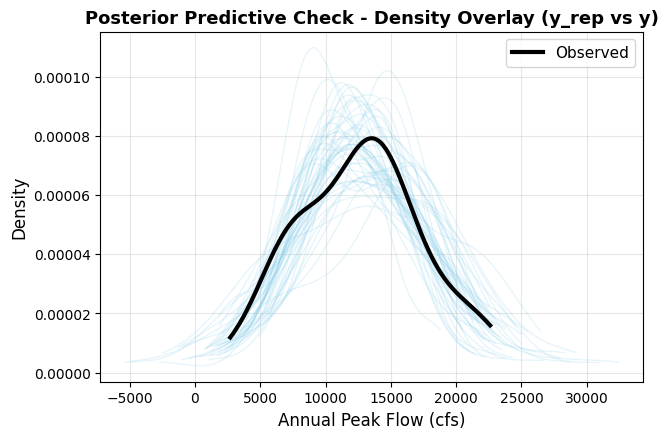

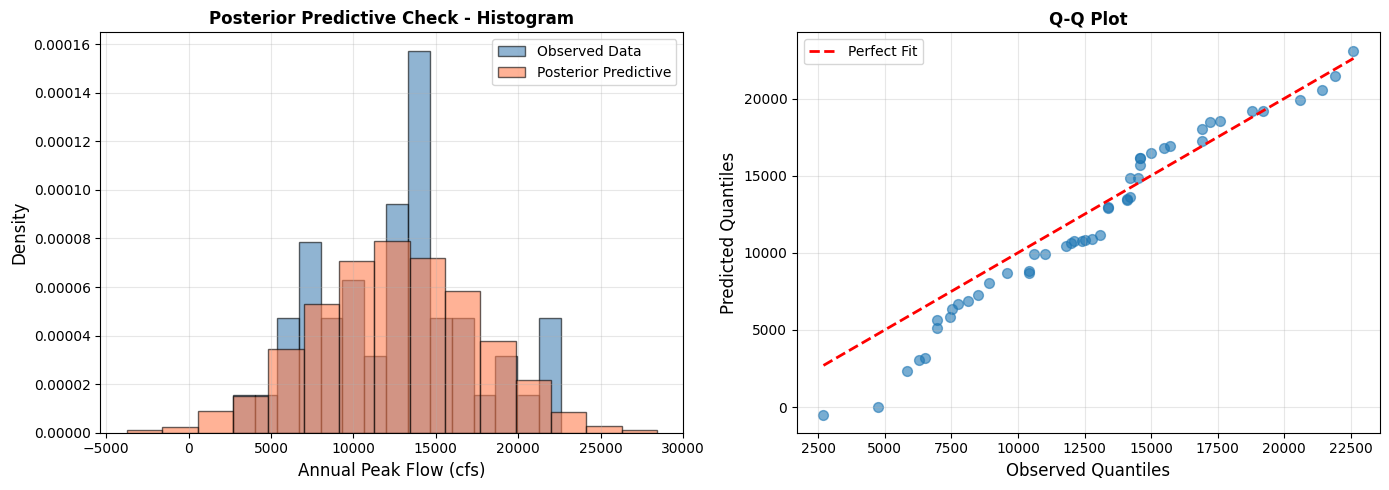


Posterior Predictive Summary


,Statistic,Observed,Posterior Predictive
0,Mean,12665.21,12543.85
1,Std Dev,4709.74,4987.08
2,5th percentile,5997.50,4370.13
3,95th percentile,21120.00,20737.24


In [7]:
# Settings for replications
n_replications = 50
n_predictions = 1000

predicted_data = []
replicated_datasets = []

posterior_mu_samples = rwmh_mu[-1000:]
posterior_sigma_samples = rwmh_sigma[-1000:]

# Draw posterior predictive values for distribution-level comparison (histogram, summary stats)
for _ in range(n_predictions):
    # Generate random index of our posterior
    idx = np.random.randint(0, len(posterior_mu_samples))
    # Pull that random sample's means and sigma
    mu = posterior_mu_samples[idx]
    sigma = posterior_sigma_samples[idx]
    # Fit a new distribution based on the drawn posterior values
    dist = Normal(mu, sigma)
    # Generate new data point from this new distribution
    # Characterize posterior
    predicted_data.append(list(dist.GenerateRandomValues(1))[0])

# Generate replicated datasets for density overlay
for _ in range(n_replications):
    # Generate random index of our posterior
    idx = np.random.randint(0, len(posterior_mu_samples))
    # Pull that random sample's mean and sigma
    mu = posterior_mu_samples[idx]
    sigma = posterior_sigma_samples[idx]
    # Fit a new distribution based on the drawn posterior values
    dist = Normal(mu, sigma)
    # Generate full dataset of new data from this distribution
    # Used for posterior check
    replicated_data = list(dist.GenerateRandomValues(len(flood_data)))
    replicated_datasets.append(replicated_data)

# Plot posterior predictive vs observed
fig = plt.figure(figsize=(7,10))
ax_density = fig.add_subplot(211)
for rep_data in replicated_datasets:
    kde = stats.gaussian_kde(rep_data)
    x_range = np.linspace(min(rep_data), max(rep_data), 200)
    ax_density.plot(x_range, kde(x_range), color='skyblue', alpha=0.2, linewidth=1)

observed_data = np.array(list(flood_data))
kde_obs = stats.gaussian_kde(observed_data)
x_range_obs = np.linspace(observed_data.min(), observed_data.max(), 200)
ax_density.plot(x_range_obs, kde_obs(x_range_obs), color='black', linewidth=3, label='Observed', zorder=10)
ax_density.set_xlabel('Annual Peak Flow (cfs)', fontsize=12)
ax_density.set_ylabel('Density', fontsize=12)
ax_density.set_title('Posterior Predictive Check - Density Overlay (y_rep vs y)', fontsize=13, fontweight='bold')
ax_density.legend(fontsize=11)
ax_density.grid(True, alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(observed_data, bins=15, density=True, alpha=0.6, color='steelblue', label='Observed Data', edgecolor='black')
ax1.hist(predicted_data, bins=15, density=True, alpha=0.6, color='coral', label='Posterior Predictive', edgecolor='black')
ax1.set_xlabel('Annual Peak Flow (cfs)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Posterior Predictive Check - Histogram', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

sorted_observed = np.sort(observed_data)
sorted_predicted = np.sort(predicted_data[:len(observed_data)])
ax2.scatter(sorted_observed, sorted_predicted, alpha=0.6, s=50)
ax2.plot([min(sorted_observed), max(sorted_observed)], [min(sorted_observed), max(sorted_observed)], 'r--', linewidth=2, label='Perfect Fit')
ax2.set_xlabel('Observed Quantiles', fontsize=12)
ax2.set_ylabel('Predicted Quantiles', fontsize=12)
ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ppc_summary = pd.DataFrame({
    'Statistic': ['Mean', 'Std Dev', '5th percentile', '95th percentile'],
    'Observed': [np.mean(observed_data), np.std(observed_data, ddof=1), np.percentile(observed_data, 5), np.percentile(observed_data, 95)],
    'Posterior Predictive': [np.mean(predicted_data), np.std(predicted_data, ddof=1), np.percentile(predicted_data, 5), np.percentile(predicted_data, 95)]
})

print("\nPosterior Predictive Summary")
display(ppc_summary.round(2))


## Linear Regression with Uncertainty
We can estimate regression coefficients with MCMC and quantify uncertainty with credible intervals [[2]](#2). We give each coefficient of the linear regression equation a prior distribution and estimate a posterior distribution. Meaning in $y = a + bx + \epsilon$, where $\epsilon \sim N(0,\sigma^2)$, $a$, $b$, and $\sigma$ all get their own prior distribution. Then our sampler produces a posterior distribution for each of these parameters. Our final estimate for these parameters is the mean of the posterior that we compare to our observed data in our final fitted line.

We go into more detail on this topic in notebook 10!


Bayesian Linear Regression Summary


,Parameter,True,Posterior Mean,Lower 90% CI,Upper 90% CI
0,a (intercept),2.0,2.092,1.789,2.401
1,b (slope),1.5,1.487,1.434,1.539
2,σ (noise sd),1.0,0.668,0.562,0.795


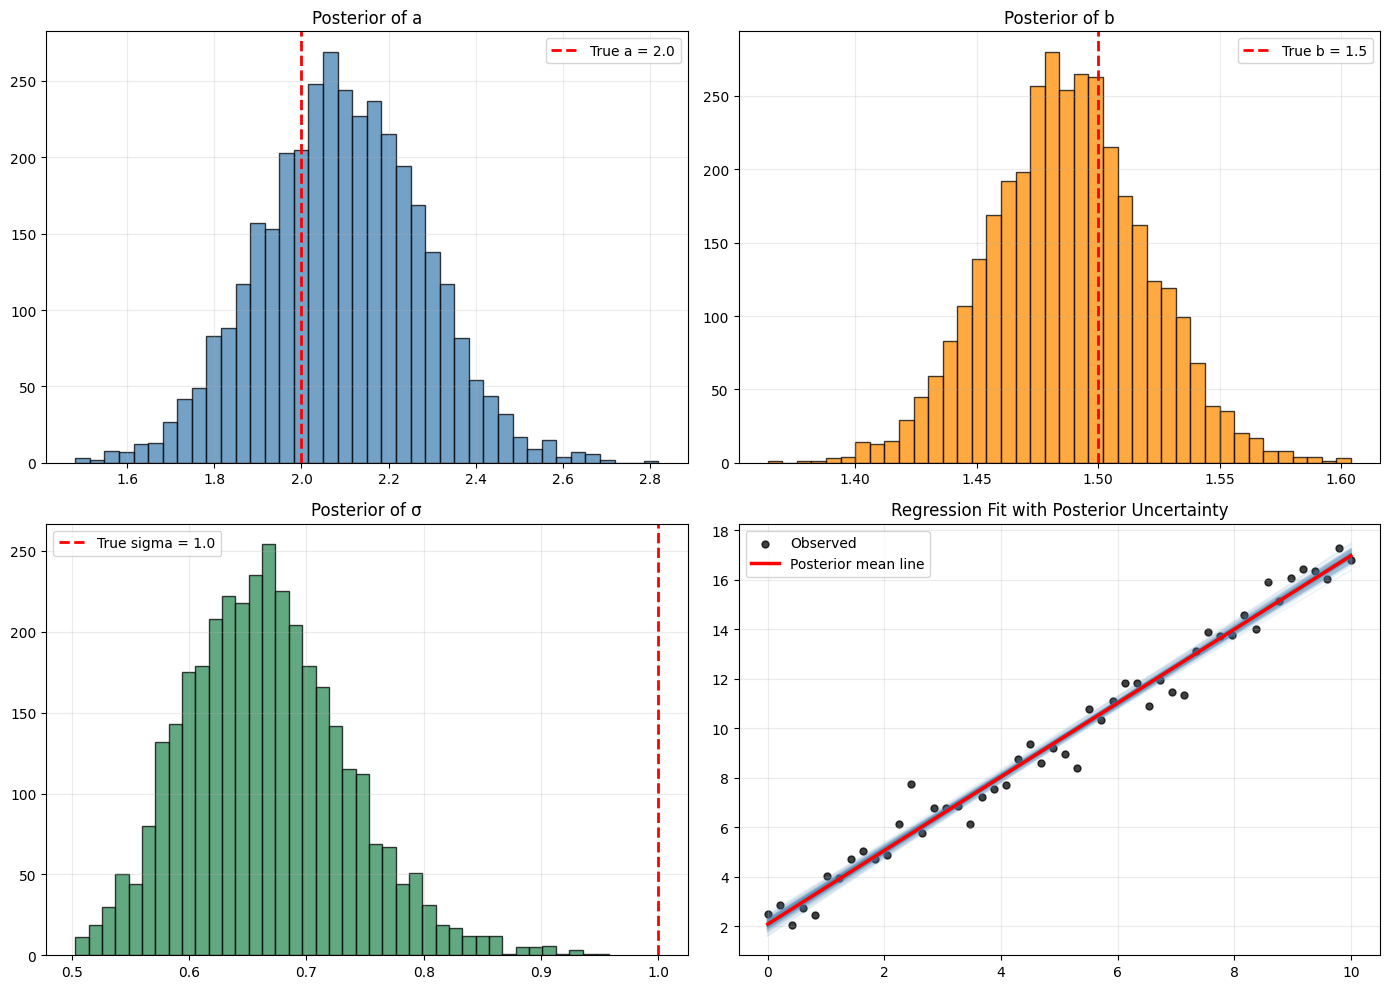

In [8]:
# Linear regression with uncertainty (y = a + b x + epsilon)
x = np.linspace(0, 10, 50)
true_a, true_b, true_sigma = 2.0, 1.5, 1.0
y = true_a + true_b * x + list(Normal(0, true_sigma).GenerateRandomValues(len(x), 123))
data = Array[Double](y)

# Priors: a ~ Uniform, b ~ Uniform, sigma ~ Uniform
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(-10, 10))
priors.Add(Uniform(0, 5))
priors.Add(Uniform(0.1, 5))

def log_likelihood_lin(params):
    a, b, sigma = params[0], params[1], params[2]
    mu = a + b * x
    dist = Normal(0, sigma)
    return sum(dist.LogPDF(y[i] - mu[i]) for i in range(len(y)))

log_lik = LogLikelihood(log_likelihood_lin)

# Run sampler
sampler_lr = RWMH(priors, log_lik, Matrix(3))
sampler_lr.ParallelizeChains = False
sampler_lr.Initialize = MCMCSampler.InitializationType.MAP
sampler_lr.Sample()
results_lr = MCMCResults(sampler_lr)

# Pull out posterior chains for each coefficient (for plotting)
a_samples = [results_lr.MarkovChains[0][i].Values[0] for i in range(len(results_lr.MarkovChains[0]))]
b_samples = [results_lr.MarkovChains[0][i].Values[1] for i in range(len(results_lr.MarkovChains[0]))]
sigma_samples = [results_lr.MarkovChains[0][i].Values[2] for i in range(len(results_lr.MarkovChains[0]))]

# Pull out posterior values
lr_summary = pd.DataFrame([
    {'Parameter':'a (intercept)','True':true_a,'Posterior Mean':results_lr.ParameterResults[0].SummaryStatistics.Mean,'Lower 90% CI':results_lr.ParameterResults[0].SummaryStatistics.LowerCI,'Upper 90% CI':results_lr.ParameterResults[0].SummaryStatistics.UpperCI},
    {'Parameter':'b (slope)','True':true_b,'Posterior Mean':results_lr.ParameterResults[1].SummaryStatistics.Mean,'Lower 90% CI':results_lr.ParameterResults[1].SummaryStatistics.LowerCI,'Upper 90% CI':results_lr.ParameterResults[1].SummaryStatistics.UpperCI},
    {'Parameter':'σ (noise sd)','True':true_sigma,'Posterior Mean':results_lr.ParameterResults[2].SummaryStatistics.Mean,'Lower 90% CI':results_lr.ParameterResults[2].SummaryStatistics.LowerCI,'Upper 90% CI':results_lr.ParameterResults[2].SummaryStatistics.UpperCI},
])
print('Bayesian Linear Regression Summary')
display(lr_summary.round(3))

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs[0, 0].hist(a_samples, bins=40, color='steelblue', alpha=0.75, edgecolor='black')
axs[0, 0].axvline(true_a, color='red', linestyle='--', linewidth=2, label=f'True a = {true_a}')
axs[0, 0].set_title('Posterior of a')
axs[0, 0].legend()

axs[0, 1].hist(b_samples, bins=40, color='darkorange', alpha=0.75, edgecolor='black')
axs[0, 1].axvline(true_b, color='red', linestyle='--', linewidth=2, label=f'True b = {true_b}')
axs[0, 1].set_title('Posterior of b')
axs[0, 1].legend()

axs[1, 0].hist(sigma_samples, bins=40, color='seagreen', alpha=0.75, edgecolor='black')
axs[1, 0].axvline(true_sigma, color='red', linestyle='--', linewidth=2, label=f'True sigma = {true_sigma}')
axs[1, 0].set_title('Posterior of σ')
axs[1, 0].legend()

axs[1, 1].scatter(x, y, alpha=0.75, color='black', s=25, label='Observed')
x_line = np.linspace(x.min(), x.max(), 200)
draw_idx = np.random.choice(len(a_samples), size=min(100, len(a_samples)), replace=False)
for idx in draw_idx:
    axs[1, 1].plot(x_line, a_samples[idx] + b_samples[idx] * x_line, color='steelblue', alpha=0.08)
mean_a = results_lr.ParameterResults[0].SummaryStatistics.Mean
mean_b = results_lr.ParameterResults[1].SummaryStatistics.Mean
axs[1, 1].plot(x_line, mean_a + mean_b * x_line, color='red', linewidth=2.5, label='Posterior mean line')
axs[1, 1].set_title('Regression Fit with Posterior Uncertainty')
axs[1, 1].legend()

for ax in axs.flat:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Non-Adaptive vs Adaptive Samplers
Samplers are usually separated by adaptive vs non-adaptive. The key idea behind adaptive MCMC is to learn the proposal covariance from the chain's own history, eliminating the need for manual tuning [[3]](#3). RWMH is a non-adaptive baseline, while DEMCzs is an adaptive method. Normally, we would not compare an adaptive method with a non-adaptive method, but here we do so to show the run time difference and improved accuracy. We will go more in depth on adaptive methods in notebook 05, but this is to get you thinking ahead!

DEMCzs is often more efficient than RWMH for:
- High-dimensional problems
- Correlated parameters
- Multimodal distributions

DEMCzs is the DEMCz algorithm with Snooker Update -- we will discuss the mathematical foundation behind DEMCz later in notebook 05.

We will fit both RWMH and DEMCzs on our flood frequency data.

Prior for μ: Uniform(-1000000, 1000000)
Prior for σ: Uniform(0, 100000)
Running RWMH sampler...
✓ RWMH complete (7.364 seconds)

Running DEMCzs sampler...
✓ DEMCzs complete (6.559 seconds)

Speedup: DEMCzs is 1.12x faster than RWMH


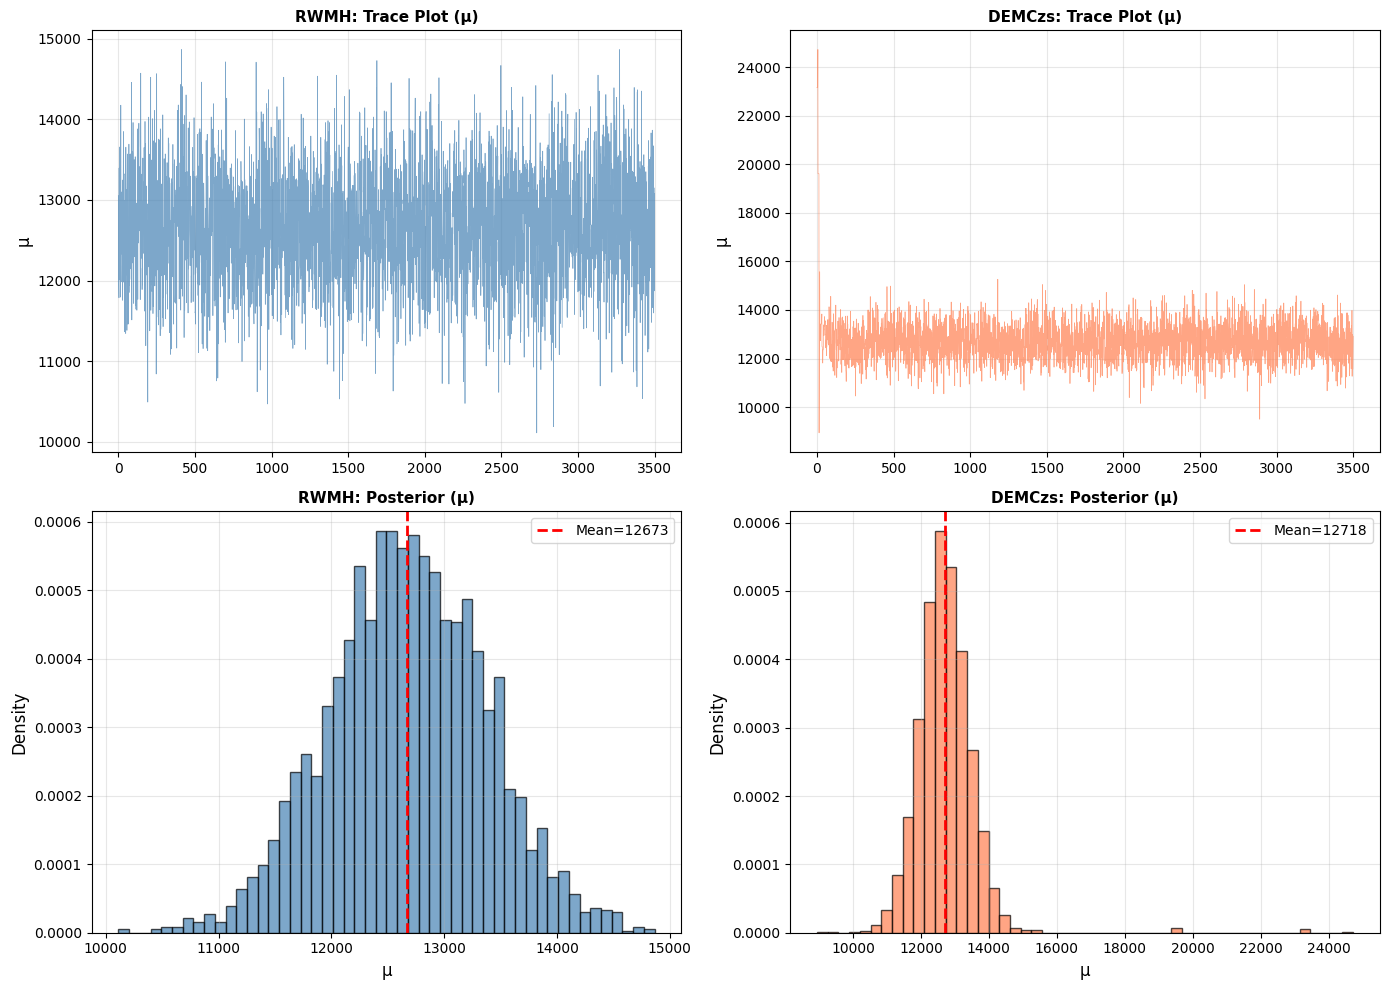

SAMPLER COMPARISON


,Statistic,RWMH,DEMCzs
0,Mean (μ),12664.471945,12655.494263
1,Std (μ),703.698295,701.338153
2,Mean (σ),4834.053320,4838.838605
3,Std (σ),514.951436,513.493502
4,Runtime (sec),7.363752,6.559430


In [9]:
# Create uniform priors based on data constraints
norm_dist = Normal()
constraints = norm_dist.GetParameterConstraints(flood_data)

mu_prior = Uniform(constraints.Item2[0], constraints.Item3[0])
sigma_prior = Uniform(constraints.Item2[1], constraints.Item3[1])

print(f"Prior for μ: Uniform({mu_prior.Minimum:.0f}, {mu_prior.Maximum:.0f})")
print(f"Prior for σ: Uniform({sigma_prior.Minimum:.0f}, {sigma_prior.Maximum:.0f})")

# Create prior list
priors = List[IUnivariateDistribution]()
priors.Add(mu_prior)
priors.Add(sigma_prior)

# Define log-likelihood
def log_likelihood_normal(params):
    mu = params[0]
    sigma = params[1]
    dist = Normal(mu, sigma)
    return dist.LogLikelihood(flood_data)

# Recall we have to wrap the Python function as a .NET Func
log_lik_func = LogLikelihood(log_likelihood_normal)

# Run RWMH sampler
print("Running RWMH sampler...")
start_rwmh = time.perf_counter()
sampler_rwmh = RWMH(priors, log_lik_func, Matrix(2))
sampler_rwmh.ParallelizeChains = False
sampler_rwmh.Initialize = MCMCSampler.InitializationType.MAP
sampler_rwmh.Sample()
time_rwmh = time.perf_counter() - start_rwmh
results_rwmh = MCMCResults(sampler_rwmh)
print(f"✓ RWMH complete ({time_rwmh:.3f} seconds)")

# Run DEMCzs sampler
print("\nRunning DEMCzs sampler...")
start_demczs = time.perf_counter()
sampler_demczs = DEMCzs(priors, log_lik_func)
sampler_demczs.ParallelizeChains = False
sampler_demczs.Sample()
time_demczs = time.perf_counter() - start_demczs
results_demczs = MCMCResults(sampler_demczs)
print(f"✓ DEMCzs complete ({time_demczs:.3f} seconds)")

print(f"\nSpeedup: DEMCzs is {time_rwmh/time_demczs:.2f}x faster than RWMH")

# Extract samples
rwmh_mu = [results_rwmh.MarkovChains[0][i].Values[0] for i in range(len(results_rwmh.MarkovChains[0]))]
rwmh_sigma = [results_rwmh.MarkovChains[0][i].Values[1] for i in range(len(results_rwmh.MarkovChains[0]))]

demczs_mu = [results_demczs.MarkovChains[0][i].Values[0] for i in range(len(results_demczs.MarkovChains[0]))]
demczs_sigma = [results_demczs.MarkovChains[0][i].Values[1] for i in range(len(results_demczs.MarkovChains[0]))]

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mu trace plots
axes[0, 0].plot(rwmh_mu, linewidth=0.5, alpha=0.7, color='steelblue')
axes[0, 0].set_ylabel('μ', fontsize=12)
axes[0, 0].set_title('RWMH: Trace Plot (μ)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(demczs_mu, linewidth=0.5, alpha=0.7, color='coral')
axes[0, 1].set_ylabel('μ', fontsize=12)
axes[0, 1].set_title('DEMCzs: Trace Plot (μ)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Mu posterior distributions
axes[1, 0].hist(rwmh_mu, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 0].axvline(np.mean(rwmh_mu), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(rwmh_mu):.0f}')
axes[1, 0].set_xlabel('μ', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('RWMH: Posterior (μ)', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(demczs_mu, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1, 1].axvline(np.mean(demczs_mu), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(demczs_mu):.0f}')
axes[1, 1].set_xlabel('μ', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('DEMCzs: Posterior (μ)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table
comparison_df = pd.DataFrame({
    'Statistic': ['Mean (μ)', 'Std (μ)', 'Mean (σ)', 'Std (σ)', 'Runtime (sec)'],
    'RWMH': [
        results_rwmh.ParameterResults[0].SummaryStatistics.Mean,
        results_rwmh.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_rwmh.ParameterResults[1].SummaryStatistics.Mean,
        results_rwmh.ParameterResults[1].SummaryStatistics.StandardDeviation,
        time_rwmh
    ],
    'DEMCzs': [
        results_demczs.ParameterResults[0].SummaryStatistics.Mean,
        results_demczs.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_demczs.ParameterResults[1].SummaryStatistics.Mean,
        results_demczs.ParameterResults[1].SummaryStatistics.StandardDeviation,
        time_demczs
    ]
})

print("SAMPLER COMPARISON")
display(comparison_df)

## Summary
In this notebook you:

$\checkmark$ Applied Bayesian inference to real flood-frequency data     
$\checkmark$ Fit multiple distributions with MCMC and compared posterior parameter estimates     
$\checkmark$ Performed posterior predictive checks to evaluate model realism  
$\checkmark$ Built a Bayesian linear regression with credible intervals on model parameters  
$\checkmark$ Learned the basics of the differences between adaptive and non-adaptive samplers

Key takeaway: Bayesian workflows in Numerics provide practical uncertainty quantification while remaining competitive in performance.

## Exercise
1. Fit a Gumbel distribution with both RWMH and DEMCzs
2. Compare posterior means and credible intervals
3. Which sampler mixes faster?



## References

<a id="1">[1]</a> N. L. Johnson, S. Kotz, and N. Balakrishnan, *Continuous Univariate Distributions*, vols. 1-2, 2nd ed. Wiley, 1994.

<a id="2">[2]</a> A. Gelman, J. B. Carlin, H. S. Stern, D. B. Dunson, A. Vehtari, and D. B. Rubin, *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013.

<a id="3">[3]</a> C. J. F. ter Braak and J. A. Vrugt, "Differential evolution Markov chain with snooker updater and fewer chains," *Statistics and Computing*, vol. 18, no. 4, pp. 435-446, 2008.
